In [1]:
import logging

import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.stats import mannwhitneyu, spearmanr

import scarf
from scarf import cytebase
from scarf.plotting import CategoricalScale, CellField, NormalizationSpec

# Keep routine progress messages out of the teaching output.
scarf.configure_output(level="WARNING", progress=False)
# HF retry messages include request URLs; keep them out of shared outputs.
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
# Keep printed tables wide enough for the selected metadata.
pd.set_option("display.width", 160)

# Connect to the public Cytebase catalog.
catalog = cytebase.Catalog()  # Public Cytebase unless CYTEBASE_BUCKET is set.

In [2]:
# Search the catalog for the dataset used in this example.
matches = catalog.search("wilk sars cov 2", ready_only=True, max_cell_chars=None)
# Summarize matching cohorts without letting full IDs dominate the table.
match_preview = matches.to_markdown(
    columns=["cytebase_id", "title", "cell_count"], max_cell_chars=32
)
# Display the cohort preview; result rows retain their complete identifiers.
display(Markdown(match_preview))

# Stop if the published COVID-19 cohort is unavailable.
if not matches:
    raise RuntimeError("The Wilk COVID-19 dataset is not ready in this catalog")
# Keep the dataset identifier returned by the catalog.
dataset_id = matches[0]["cytebase_id"]
# Read the dataset's scientific metadata and citation.
entry = catalog.dataset(dataset_id)
# Inspect the dataset record and source citation.
entry

| Cytebase ID | Title | Cells |
| --- | --- | ---: |
| wilk&#95;2020&#95;single&#95;cell&#95;atlas&#95;per… | Single-cell atlas of peripheral… | 44,721 |

1 row. Long cells are shortened; use `max_cell_chars=None` to display complete values. Row dictionaries retain the full values.

### Single-cell atlas of peripheral immune response to SARS-CoV-2 infection

- **Cytebase ID:** `wilk_2020_single_cell_atlas_peripheral_sars_cov_2_infection_456e8b9b`
- **Citation:**
    - Publication: https://doi.org/10.1038/s41591-020-0944-y
    - Dataset Version: https://datasets.cellxgene.cziscience.com/8d7fad46-2f37-4aa0-ac9d-babbc36efb6f.h5ad
    - curated and distributed by CZ CELLxGENE Discover in Collection: https://cellxgene.cziscience.com/collections/a72afd53-ab92-4511-88da-252fb0e26b9a
- **DOI:** 10.1038/s41591-020-0944-y
- **CELLxGENE:** https://cellxgene.cziscience.com/collections/a72afd53-ab92-4511-88da-252fb0e26b9a
- **Explorer:** https://cellxgene.cziscience.com/e/456e8b9b-f872-488b-871d-94534090a865.cxg/
- **Size:** 44,721 cells, 24,505 genes
- **Status:** ready
- **Organisms:** Homo sapiens
- **Assays:** Seq-Well
- **Tissues:** blood
- **Diseases:** COVID-19, normal
- **Suspension:** cell
- **Source embeddings:** X_pca, X_umap

In [3]:
# Open the datastore for the following analysis.
ds = catalog.open_datastore(entry.id)
# Inspect the remote datastore dimensions and assays.
print(ds)
# List the imported embeddings before selecting the UMAP.
print("\nImported embeddings:", sorted(cytebase.embeddings(ds)))
# Select the imported UMAP without recomputing its coordinates.
umap_ref = cytebase.embedding(ds, "X_umap")

DataStore has 44721 (44721) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'Admission', 'DPS', 
            'DTF', 'HLA1', 'IFN1', 'RNA_nCounts', 'RNA_nFeatures', 
            'RNA_percentMito', 'RNA_percentRibo', 'Ventilated', 'assay', 'assay_ontology_term_id', 
            'cell.type.coarse', 'cell.type.fine', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 
            'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 
            'nCount_RNA', 'nCount_SCT', 'nFeature_RNA', 'nFeature_SCT', 'observation_joinid', 
            'percent.mt', 'percent.rpl', 'percent.rps', 'percent.rrna', 'self_reported_ethnicity', 
            'self_reported_ethnicity_ontology_term_id', 'seurat_clusters', 'sex', 'sex_ontology_term_id', 'singler', 
            'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_type'
   RNA assay has 24505 features and following metadata:
            'I', 'id


Imported embeddings: ['X_umap']


In [4]:
# Choose the study-design and annotation fields needed below.
columns = [
    "cell_type",
    "cell.type.coarse",
    "disease",
    "donor_id",
    "Ventilated",
    "Admission",
    "DPS",
    "sex",
    "development_stage",
    "IFN1",
]
# Read cell metadata and index it by cell ID.
meta = ds.cells.to_pandas_dataframe(["ids", *columns], key="I").set_index("ids")
# Check how many cells and metadata columns were loaded.
print(f"{len(meta):,} cells, {meta.shape[1]} metadata columns read")

44,721 cells, 10 metadata columns read


In [5]:
# Combine distinct donor metadata values without hiding repeated samples.
def distinct(values):
    return " / ".join(map(str, sorted(values.unique())))


# Summarize the study metadata and cell count per donor.
donors = meta.groupby("donor_id").agg(
    disease=("disease", "first"),
    ventilated=("Ventilated", distinct),
    admission=("Admission", distinct),
    days_post_symptoms=("DPS", distinct),
    sex=("sex", "first"),
    age=("development_stage", "first"),
    cells=("disease", "size"),
)
# Inspect one clinical and cell-count summary per donor.
donors

,disease,ventilated,admission,days_post_symptoms,sex,age,cells
donor_id,,,,,,,
C1,COVID-19,NonVent / Vent,ICU,9 / 11,male,seventh decade stage,8362
C2,COVID-19,NonVent,ICU,16,male,fifth decade stage,1735
C3,COVID-19,Vent,ICU,9,male,fourth decade stage,6545
C4,COVID-19,Vent,ICU,9,male,fourth decade stage,3688
C5,COVID-19,NonVent,ICU,15,male,sixth decade stage,2507
C6,COVID-19,Vent,ICU,2,male,80 year-old and over stage,1893
C7,COVID-19,NonVent,Floor,12,male,third decade stage,3364
H1,normal,Healthy,N/A,0,female,49-year-old stage,2100
H2,normal,Healthy,N/A,0,male,49-year-old stage,1941


In [6]:
# Count cells of each published type in each condition.
by_type = pd.crosstab(meta["cell_type"], meta["disease"])
# Match each detailed cell type to the authors' coarse label.
coarse_labels = meta.groupby("cell_type")["cell.type.coarse"].first()
# Place each coarse label beside its detailed cell-type counts.
by_type.insert(0, "coarse label", coarse_labels)
# Compare condition counts with the authors' shorter cell-type labels.
by_type.sort_values(["coarse label", "COVID-19"], ascending=[True, False])

disease,coarse label,COVID-19,normal
cell_type,,,
B cell,B,1715,1966
class switched memory B cell,B,1313,28
CD14-positive monocyte,CD14 Monocyte,8285,2054
monocyte,CD16 Monocyte,433,915
"CD4-positive, alpha-beta memory T cell",CD4 T,2890,1208
naive T cell,CD4 T,2224,1616
"CD4-positive, alpha-beta T cell",CD4 T,448,11
"CD8-positive, alpha-beta memory T cell",CD8 T,3312,2753
"effector CD8-positive, alpha-beta T cell",CD8 T,565,132


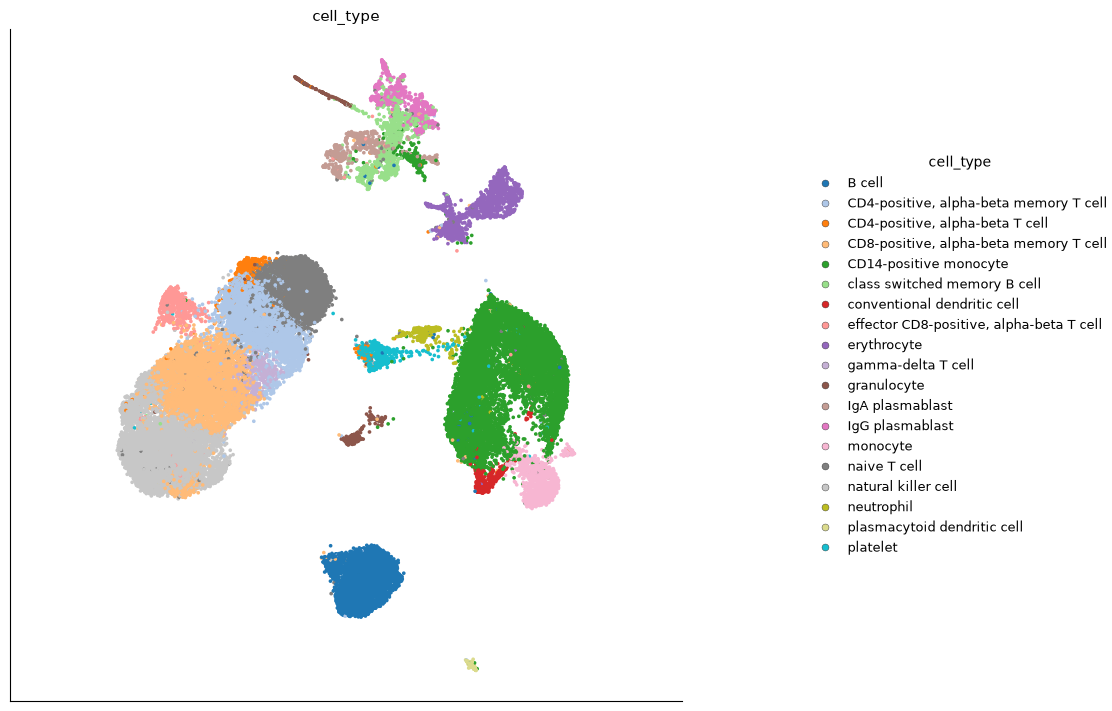

In [7]:
# Show the published Cell Ontology labels on the imported UMAP.
ds.plots.embedding(
    layout=umap_ref,
    color_by="cell_type",
    legend_loc="right",
    figsize=(12, 7),
)

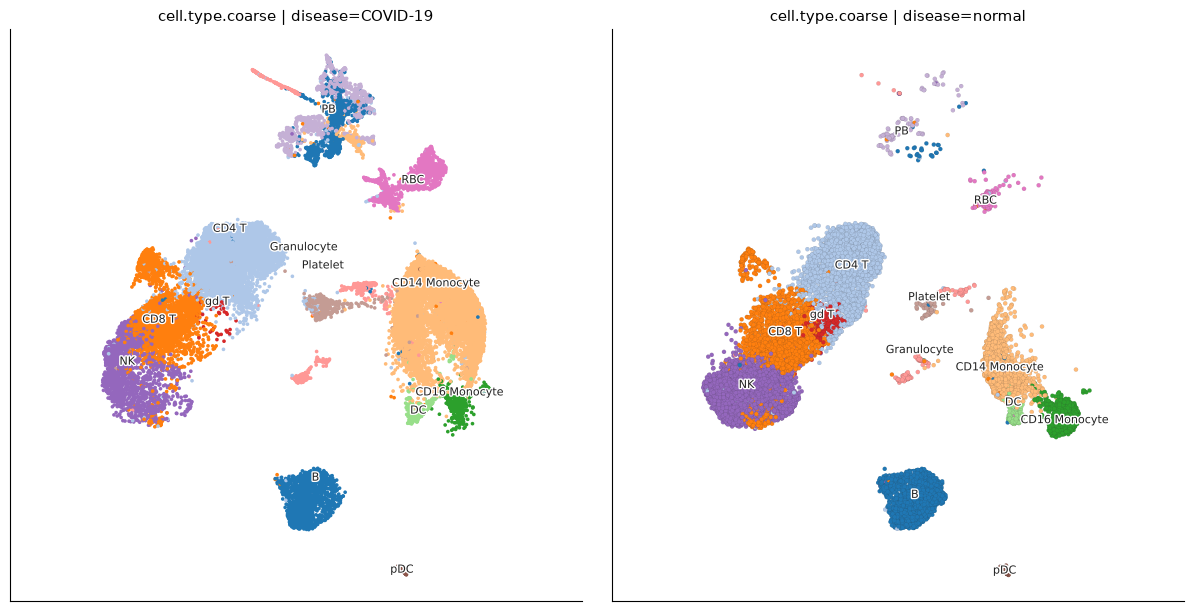

In [8]:
# Compare the two conditions on matching UMAP panels.
ds.plots.embedding(
    layout=umap_ref,
    color_by="cell.type.coarse",
    facet_by="disease",
    figsize=(12, 6),
)

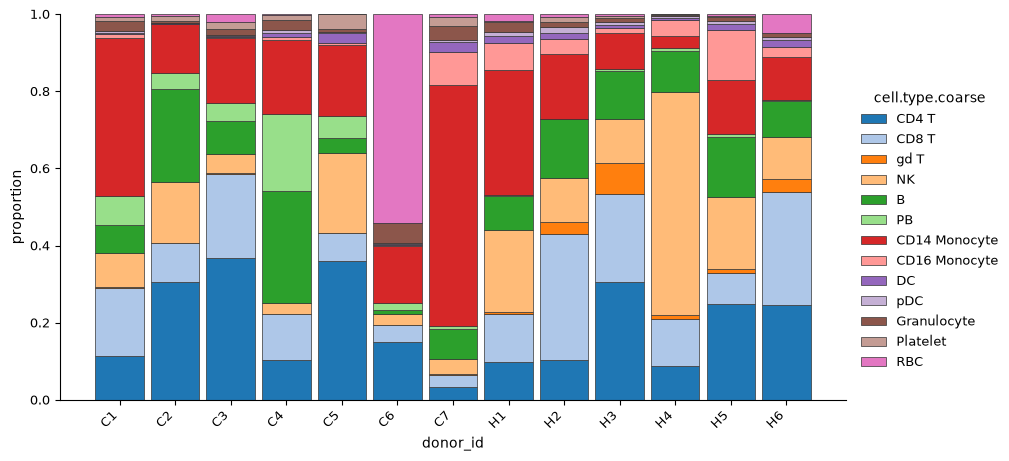

In [9]:
# Use the same cell-type order across composition figures.
coarse_order = [
    "CD4 T",
    "CD8 T",
    "gd T",
    "NK",
    "B",
    "PB",
    "CD14 Monocyte",
    "CD16 Monocyte",
    "DC",
    "pDC",
    "Granulocyte",
    "Platelet",
    "RBC",
]
# Keep category colors consistent across those figures.
coarse_scale = CategoricalScale(order=tuple(coarse_order))

# Compare cell-type composition with one summary per donor.
ds.plots.composition(
    category_by="cell.type.coarse",
    sample_by="donor_id",
    kind="stacked",
    categorical_scale=coarse_scale,
    figsize=(10, 4.5),
)

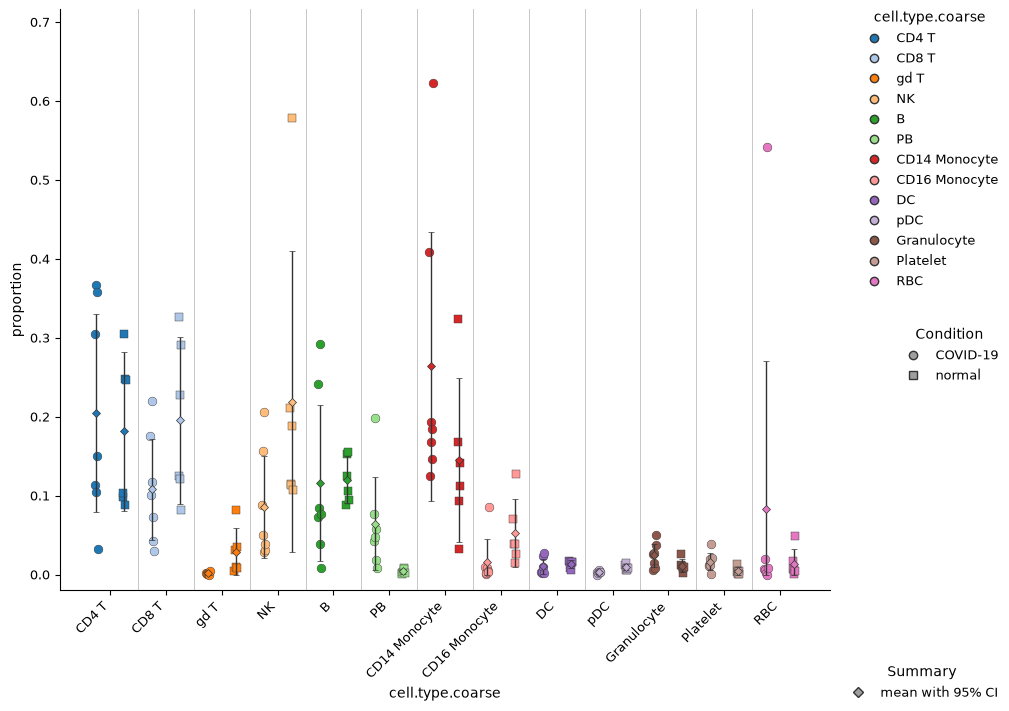

In [10]:
# Compare cell-type composition with one summary per donor.
ds.plots.composition(
    category_by="cell.type.coarse",
    sample_by="donor_id",
    condition_by="disease",
    kind="per_sample",
    categorical_scale=coarse_scale,
    figsize=(10, 7),
    max_figure_width=None,
)

In [11]:
# Calculate cell-type proportions separately within each donor.
fractions = pd.crosstab(
    meta["donor_id"], meta["cell.type.coarse"], normalize="index"
)
# Choose the cell types highlighted in the comparison.
shown = ["PB", "CD16 Monocyte", "gd T", "pDC", "NK", "RBC"]
# Attach each donor's condition to the composition summary.
fraction_table = fractions[shown].join(donors["disease"])
# Summarize the donor-level fractions within each disease group.
fraction_table.groupby("disease")[shown].agg(["min", "median", "max"]).T.round(3)

disease               COVID-19  normal
PB            min        0.009   0.001
              median     0.048   0.003
              max        0.199   0.008
CD16 Monocyte min        0.001   0.014
              median     0.005   0.039
              max        0.086   0.128
gd T          min        0.000   0.005
              median     0.001   0.020
              max        0.004   0.082
pDC           min        0.000   0.006
              median     0.003   0.008
              max        0.006   0.015
NK            min        0.028   0.108
              median     0.050   0.151
              max        0.207   0.579
RBC           min        0.000   0.001
              median     0.007   0.007
              max        0.542   0.049

In [12]:
# Group canonical PBMC markers by the identities they support.
marker_sets = {
    "T": ["CD3E", "IL7R", "CD8A"],
    "gd T": ["TRDC"],
    "NK": ["NKG7", "GNLY"],
    "B": ["MS4A1"],
    "PB": ["MZB1", "JCHAIN"],
    "Mono": ["CD14", "LYZ", "FCGR3A"],
    "DC": ["FCER1A"],
    "pDC": ["LILRA4"],
    "Gran.": ["CSF3R"],
    "Plt": ["PPBP"],
    "RBC": ["HBB"],
}
# Choose four interferon-response genes for the next comparison.
isg_genes = ["IFI27", "ISG15", "IFI44L", "IFI6"]

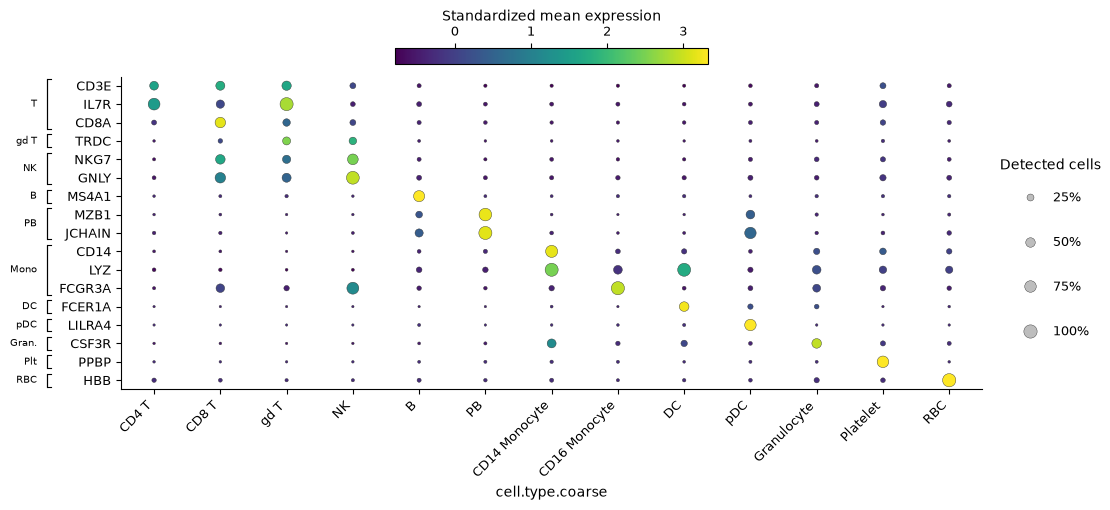

In [13]:
# Compare marker expression and detection across cell types.
ds.plots.dotplot(
    features=marker_sets,
    group_by="cell.type.coarse",
    group_order=coarse_order,
    normalization=NormalizationSpec(transform="log1p"),
    standardize="feature",
    figsize=(11, 5),
    max_figure_width=None,
)

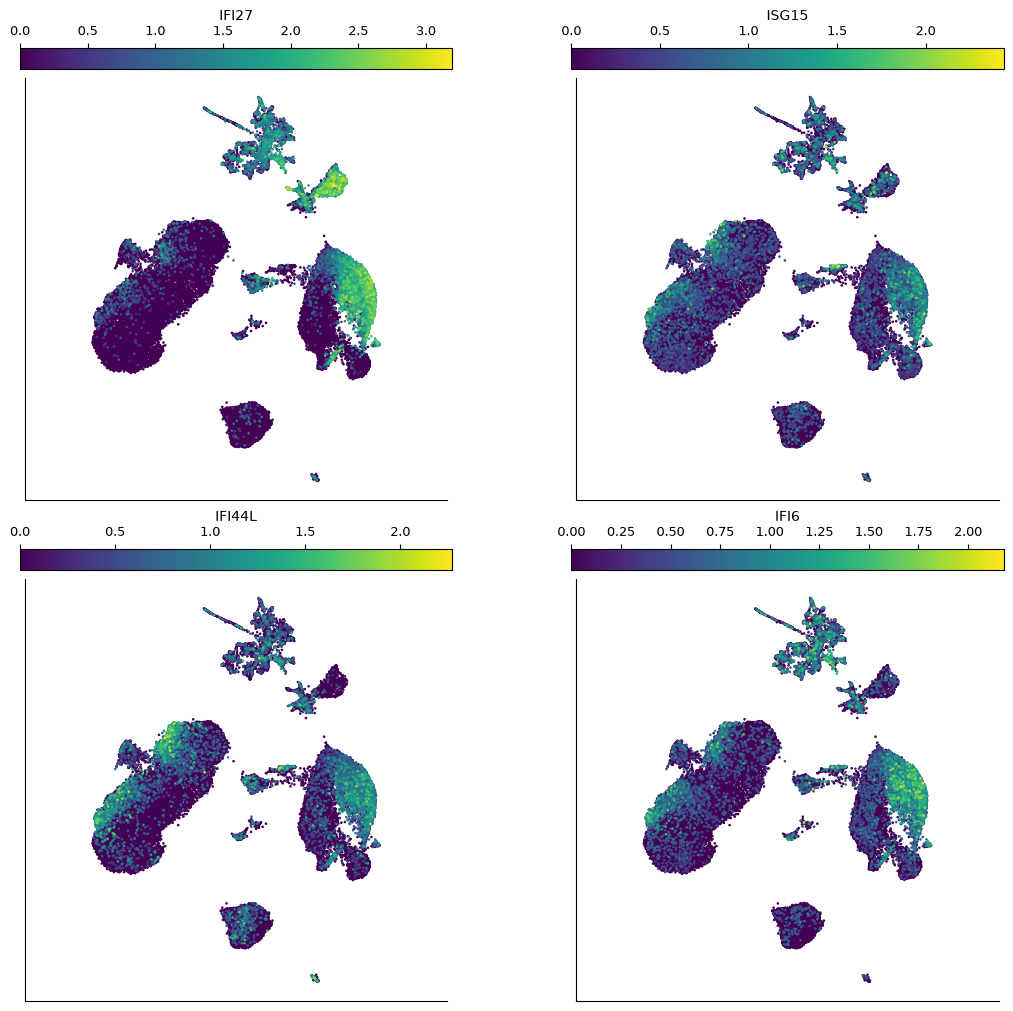

In [14]:
# Plot the four interferon-response genes on the imported UMAP.
ds.plots.embedding(
    layout=umap_ref,
    color_by=isg_genes,
    normalization=NormalizationSpec(transform="log1p"),
    sort_values=True,
    n_columns=2,
    figsize=(11, 10),
)

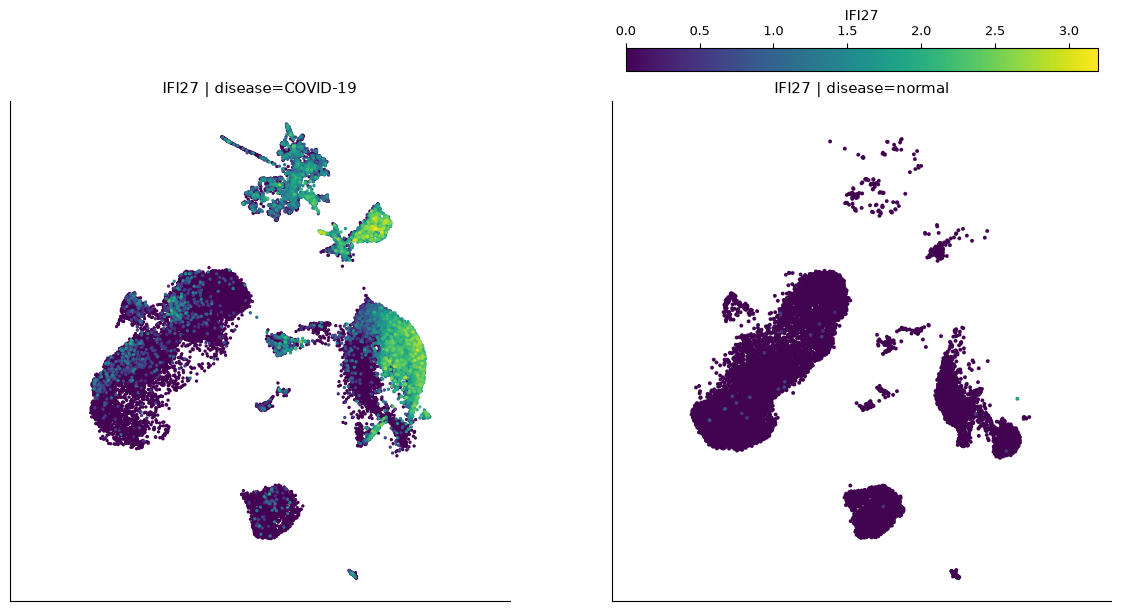

In [15]:
# Compare IFI27 expression between conditions on a shared scale.
ds.plots.embedding(
    layout=umap_ref,
    color_by=isg_genes[0],
    facet_by="disease",
    normalization=NormalizationSpec(transform="log1p"),
    sort_values=True,
    figsize=(12, 6),
)

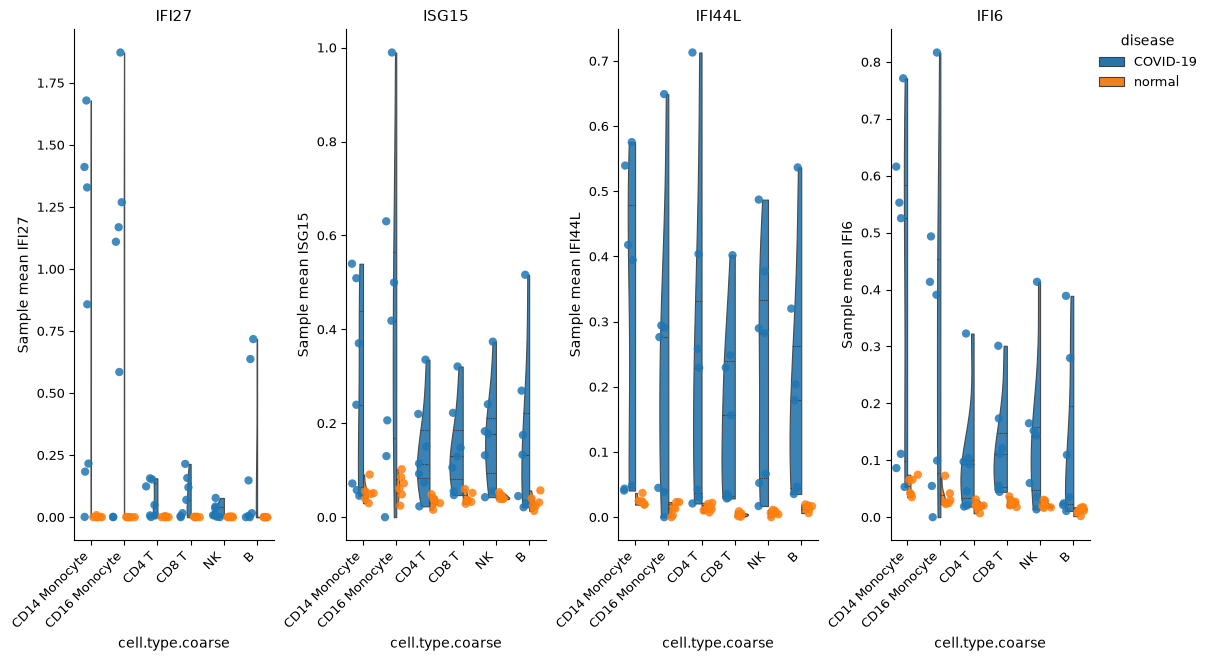

In [16]:
# Focus the donor comparison on the major immune populations.
main_types = ["CD14 Monocyte", "CD16 Monocyte", "CD4 T", "CD8 T", "NK", "B"]
# Compare distributions within the stated groups.
ds.plots.distribution(
    isg_genes,
    grouping=CellField("cell.type.coarse"),
    groups=main_types,
    split_by="disease",
    sample_by="donor_id",
    normalization=NormalizationSpec(transform="log1p"),
    share_y=False,
    point_size=6,
    point_alpha=0.85,
    figsize=(12, 6.5),
    max_figure_width=None,
)

In [17]:
# Read and log-transform only the four selected genes.
expression = pd.DataFrame(
    {
        gene: np.log1p(ds.get_cell_vals(from_assay="RNA", cell_key="I", k=gene))
        for gene in isg_genes
    },
    index=meta.index,
)
# Average the four log-transformed values within each cell.
expression["ISG mean"] = expression[isg_genes].mean(axis=1)

# Preview the four-gene expression table and per-cell mean.
expression.head()

,IFI27,ISG15,IFI44L,IFI6,ISG mean
ids,,,,,
covid_555_1.1,1.960800,0.000000,0.0,0.0,0.490200
covid_555_1.2,0.000000,0.000000,0.0,0.0,0.000000
covid_555_1.3,1.765848,0.961459,0.0,0.0,0.681827
covid_555_1.7,0.000000,0.000000,0.0,0.0,0.000000
covid_555_1.8,0.926000,0.000000,0.0,0.0,0.231500


In [18]:
# Keep CD14 monocytes and their aligned expression values.
monocytes = meta.join(expression).query("`cell.type.coarse` == 'CD14 Monocyte'")
# Average gene scores within each donor's monocytes.
mono_table = monocytes.groupby("donor_id").agg(
    disease=("disease", "first"),
    admission=("Admission", distinct),
    ventilated=("Ventilated", distinct),
    monocytes=("disease", "size"),
    **{column: (column, "mean") for column in [*isg_genes, "ISG mean", "IFN1"]},
)
# Inspect the expression and clinical summary for each donor's monocytes.
mono_table.round(3)

,disease,admission,ventilated,monocytes,IFI27,ISG15,IFI44L,IFI6,ISG mean,IFN1
donor_id,,,,,,,,,,
C1,COVID-19,ICU,NonVent / Vent,3419,1.329,0.370,0.395,0.553,0.662,0.149
C2,COVID-19,ICU,NonVent,217,0.216,0.046,0.049,0.111,0.105,0.042
C3,COVID-19,ICU,Vent,1102,0.184,0.072,0.044,0.086,0.096,0.040
C4,COVID-19,ICU,Vent,713,1.411,0.239,0.418,0.525,0.648,0.155
C5,COVID-19,ICU,NonVent,462,1.679,0.540,0.539,0.771,0.882,0.193
C6,COVID-19,ICU,Vent,277,0.858,0.509,0.575,0.616,0.640,0.183
C7,COVID-19,Floor,NonVent,2095,0.001,0.058,0.041,0.053,0.038,0.065
H1,normal,N/A,Healthy,680,0.000,0.030,0.025,0.035,0.022,0.039
H2,normal,N/A,Healthy,325,0.000,0.050,0.019,0.066,0.034,0.044


In [19]:
# Select the patient donor means.
covid = mono_table.loc[mono_table["disease"] == "COVID-19", "ISG mean"]
# Select the healthy donor means.
healthy = mono_table.loc[mono_table["disease"] == "normal", "ISG mean"]
# Compare the independent donor means with a two-sided rank test.
test = mannwhitneyu(covid, healthy, alternative="two-sided")
# Compare the four-gene summary with the authors' interferon score.
rho = spearmanr(mono_table["ISG mean"], mono_table["IFN1"]).statistic

# Count patients above the highest healthy donor mean.
n_above = (covid > healthy.max()).sum()
# Show how many patient means exceed the highest healthy donor.
print(f"Patients above the highest healthy donor: {n_above} of {len(covid)}")
# Report the donor-level rank statistic and two-sided p-value.
print(
    f"Mann-Whitney U on donor means ({len(covid)} vs {len(healthy)} donors): "
    f"U = {test.statistic:.0f}, two-sided p = {test.pvalue:.4f}"
)
# Report concordance with the authors' interferon-response score.
print(
    "Spearman correlation of donor ISG mean with the authors' IFN1 score:",
    f"{rho:.2f}",
)

Patients above the highest healthy donor: 6 of 7
Mann-Whitney U on donor means (7 vs 6 donors): U = 41, two-sided p = 0.0023
Spearman correlation of donor ISG mean with the authors' IFN1 score: 0.73
